In [29]:
import pandas as pd

# Load the dataset with correct encoding for Korean files
file_path = '/content/졸업생의취업현황(대학,전문대학).csv'
try:
    df = pd.read_csv(file_path, encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='euc-kr')

# Define the target universities
target_universities = ['가천대학교', '단국대학교', '경기대학교']

# Filter the dataframe
df_filtered = df[df['학교명'].isin(target_universities)].copy()

# Display the filtered dataframe info and first few rows
print(f"Filtered dataset shape: {df_filtered.shape}")
display(df_filtered.head())

Filtered dataset shape: (513, 52)


,기준년도,학교종류명,설립구분명,학교명,단과대학명,학과명(전공),구분명,학과특성명,남자졸업자수(A)(명),여자졸업자수(A)(명),...,1차유지여자취업률(수시)(%),2차유지합계취업률(수시)(%),2차유지남자취업률(수시)(%),2차유지여자취업률(수시)(%),3차유지합계취업률(수시)(%),3차유지남자취업률(수시)(%),3차유지여자취업률(수시)(%),4차유지합계취업률(수시)(%),4차유지남자취업률(수시)(%),4차유지여자취업률(수시)(%)
0,2024,대학교,사립,가천대학교,공과대학,도시계획학전공,주간,일반과정,26,21,...,90.0,87.5,100.0,70.0,79.2,85.7,70.0,79.2,85.7,70.0
1,2024,대학교,사립,가천대학교,공과대학,기계공학과,주간,일반과정,74,11,...,100.0,97.4,97.1,100.0,94.9,94.1,100.0,92.3,91.2,100.0
2,2024,대학교,사립,가천대학교,공과대학,건축학전공,주간,일반과정,17,14,...,100.0,88.9,80.0,100.0,85.2,80.0,91.7,81.5,80.0,83.3
3,2024,대학교,사립,가천대학교,공과대학,건축학과,주간,일반과정,0,3,...,100.0,100.0,0.0,100.0,100.0,0.0,100.0,100.0,0.0,100.0
4,2024,대학교,사립,가천대학교,공과대학,건축공학전공,주간,일반과정,37,7,...,100.0,83.3,85.7,66.7,83.3,85.7,66.7,79.2,81.0,66.7


### Data Preprocessing
I will now convert columns that should be numeric (like employment rates) to appropriate types, handling any non-numeric strings that might be present.

In [30]:
# Identify columns that should be numeric (columns containing '%')
numeric_cols = [col for col in df_filtered.columns if '%' in col]

for col in numeric_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce').fillna(0)

print("Preprocessing complete. Numeric columns have been cleaned.")
display(df_filtered.describe())

Preprocessing complete. Numeric columns have been cleaned.


,기준년도,남자졸업자수(A)(명),여자졸업자수(A)(명),건강보험연계남자취업자수(B)(명),건강보험연계여자취업자수(B)(명),해외남자취업자수(B)(명),해외여자취업자수(B)(명),영농업남자종사자수(B)(명),영농업여자종사자수(B)(명),개인창작활동남자종사자수(B)(명),...,1차유지여자취업률(수시)(%),2차유지합계취업률(수시)(%),2차유지남자취업률(수시)(%),2차유지여자취업률(수시)(%),3차유지합계취업률(수시)(%),3차유지남자취업률(수시)(%),3차유지여자취업률(수시)(%),4차유지합계취업률(수시)(%),4차유지남자취업률(수시)(%),4차유지여자취업률(수시)(%)
count,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,...,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000
mean,2023.040936,27.352827,29.660819,14.469786,14.315789,0.050682,0.089669,0.015595,0.001949,0.124756,...,82.941326,82.353216,78.436647,78.304678,75.873879,73.619688,71.631579,74.624951,72.674269,70.201949
std,0.824598,30.034067,30.625860,16.089580,17.096740,0.244798,0.390000,0.124022,0.044151,0.762930,...,26.370374,21.227657,30.552017,26.314744,22.300006,30.432572,27.033315,22.253936,30.308215,27.048506
min,2022.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022.000000,9.000000,11.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,81.300000,80.000000,75.000000,73.700000,71.400000,66.700000,65.400000,69.400000,66.700000,62.500000
50%,2023.000000,19.000000,22.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,90.000000,87.500000,90.000000,85.700000,81.000000,84.600000,77.800000,80.000000,83.300000,75.000000
75%,2024.000000,34.000000,40.000000,19.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.000000,93.500000,100.000000,95.500000,88.900000,93.000000,88.900000,87.800000,91.900000,87.500000
max,2024.000000,214.000000,267.000000,124.000000,200.000000,2.000000,4.000000,1.000000,1.000000,11.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


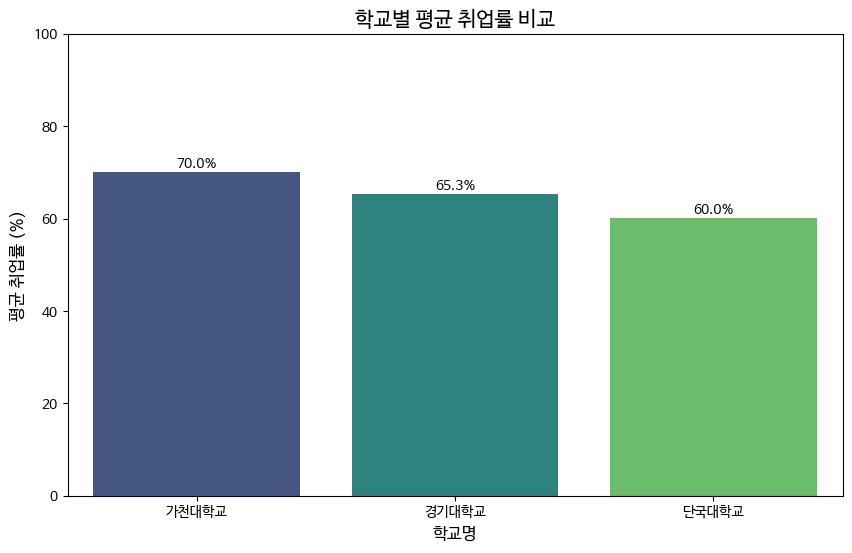

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Matplotlib 3.5+ version fix: Add font directly instead of using _rebuild()
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 취업률 컬럼 설정
employment_rate_col = '취업률(%) [B/{A-(C+D+E+F+G))]x100(%)'

# 학교별 평균 취업률 계산
avg_employment = df_filtered.groupby('학교명')[employment_rate_col].mean().reset_index()

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='학교명', y=employment_rate_col, data=avg_employment, hue='학교명', palette='viridis', legend=False)
plt.title('학교별 평균 취업률 비교', fontsize=15)
plt.xlabel('학교명', fontsize=12)
plt.ylabel('평균 취업률 (%)', fontsize=12)
plt.ylim(0, 100)

for i, row in avg_employment.iterrows():
    plt.text(i, row[employment_rate_col] + 1, f'{row[employment_rate_col]:.1f}%', ha='center')

plt.show()

### Matplotlib 한글 폰트 설정 및 오류 해결

1. `fonts-nanum` 패키지를 설치합니다.
2. `font_manager`를 사용하여 설치된 폰트 경로를 직접 지정합니다.
3. `rcParams`를 통해 한글 폰트와 마이너스 기호 깨짐을 방지합니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

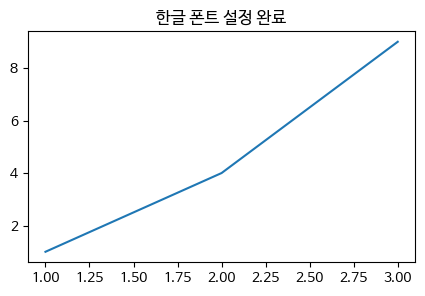

In [32]:
# 1. 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 2. 설치된 나눔바른고딕 폰트 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

# 3. Matplotlib 전역 설정 업데이트
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print(f"설정된 폰트: {font_name}")

# 확인을 위한 샘플 그래프
plt.figure(figsize=(5, 3))
plt.title('한글 폰트 설정 완료')
plt.plot([1, 2, 3], [1, 4, 9])
plt.show()

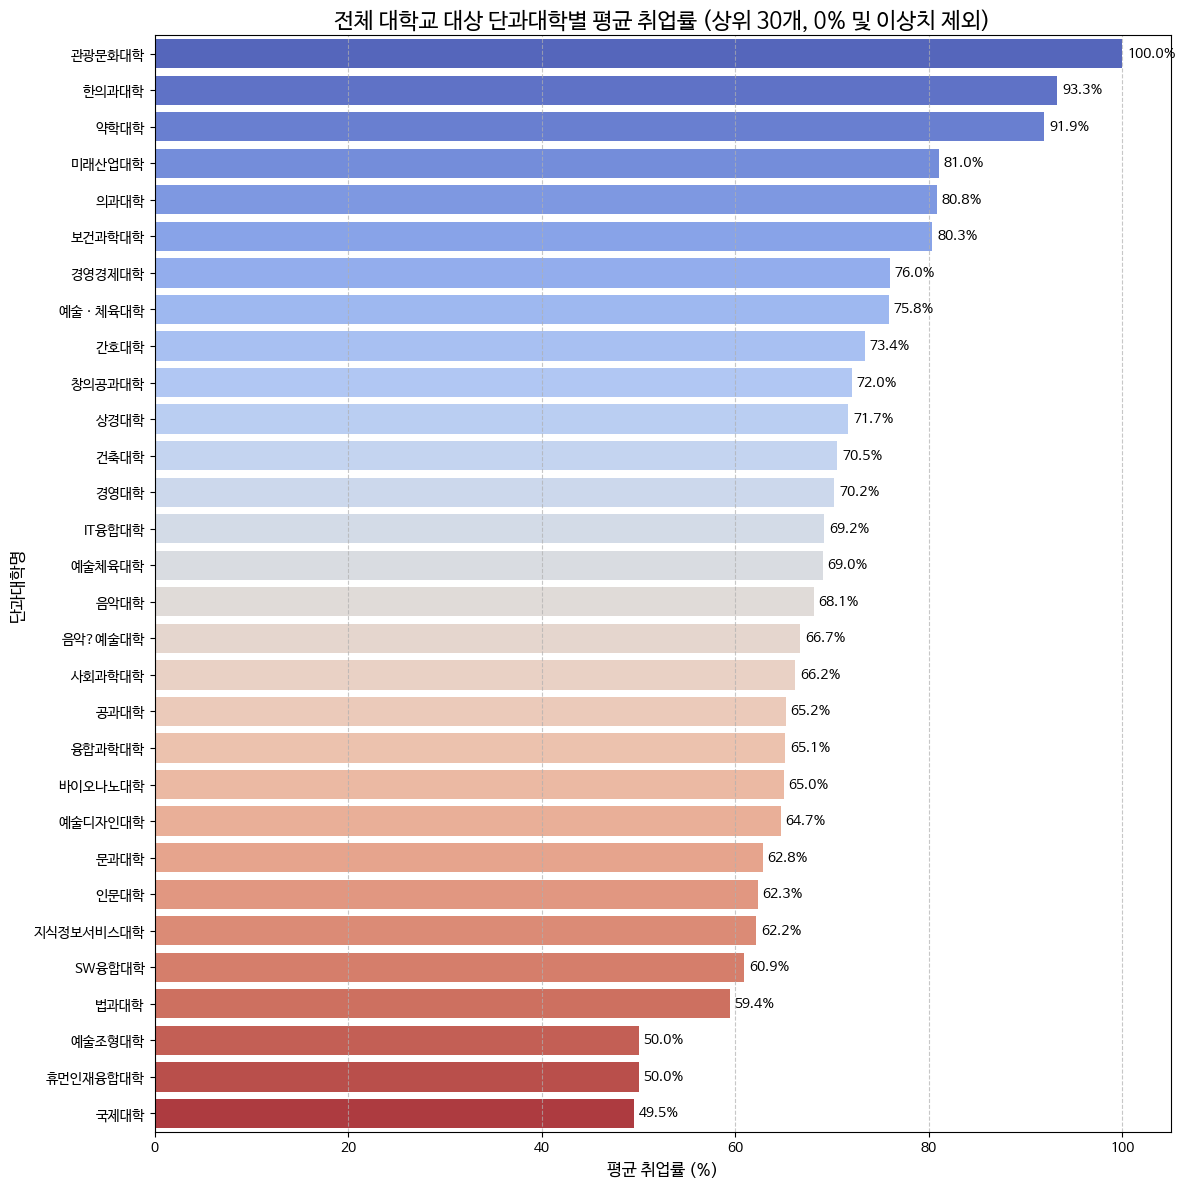

전체 단과대학 개수: 36개


,단과대학명,취업률(%) [B/{A-(C+D+E+F+G))]x100(%)
0,관광문화대학,100.000000
1,한의과대학,93.266667
2,약학대학,91.900000
3,미래산업대학,81.000000
4,의과대학,80.800000
5,보건과학대학,80.344444
6,경영경제대학,75.950000
7,예술ㆍ체육대학,75.848148
8,간호대학,73.366667
9,창의공과대학,72.008824


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 데이터(df_filtered)를 대상으로 단과대학별 평균 취업률 계산
employment_rate_col = '취업률(%) [B/{A-(C+D+E+F+G))]x100(%)'
all_college_avg_cleaned = df_filtered.groupby('단과대학명')[employment_rate_col].mean().sort_values(ascending=False).reset_index()

# 상위 30개 단과대학 시각화 (전체는 너무 많으므로)
plt.figure(figsize=(12, 12))
sns.barplot(x=employment_rate_col, y='단과대학명', data=all_college_avg_cleaned.head(30), hue='단과대학명', palette='coolwarm', legend=False)

plt.title('전체 대학교 대상 단과대학별 평균 취업률 (상위 30개, 0% 및 이상치 제외)', fontsize=16)
plt.xlabel('평균 취업률 (%)', fontsize=12)
plt.ylabel('단과대학명', fontsize=12)
plt.xlim(0, 105)

# 수치 표시
for i, row in all_college_avg_cleaned.head(30).iterrows():
    plt.text(row[employment_rate_col] + 0.5, i, f'{row[employment_rate_col]:.1f}%', va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 전체 통계 요약
print(f"전체 단과대학 개수: {len(all_college_avg_cleaned)}개")
display(all_college_avg_cleaned.head(20))

In [35]:
import numpy as np

employment_rate_col = '취업률(%) [B/{A-(C+D+E+F+G))]x100(%)'

# 1. 0% 취업률 데이터 제외 (결측치로 간주)
initial_rows = len(df_filtered)
df_filtered = df_filtered[df_filtered[employment_rate_col] != 0].copy()
removed_zeros = initial_rows - len(df_filtered)
print(f"취업률이 0%인 데이터 {removed_zeros}개를 제외했습니다.")

# 2. IQR을 이용한 이상치 제거
Q1 = df_filtered[employment_rate_col].quantile(0.25)
Q3 = df_filtered[employment_rate_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_rows_before = len(df_filtered)
df_filtered = df_filtered[(df_filtered[employment_rate_col] >= lower_bound) & (df_filtered[employment_rate_col] <= upper_bound)].copy()
outlier_removed_count = outlier_rows_before - len(df_filtered)

print(f"IQR 기준으로 이상치 데이터 {outlier_removed_count}개를 제외했습니다.")
print(f"최종적으로 정리된 데이터셋 형태: {df_filtered.shape}")

display(df_filtered.describe())

취업률이 0%인 데이터 19개를 제외했습니다.
IQR 기준으로 이상치 데이터 39개를 제외했습니다.
최종적으로 정리된 데이터셋 형태: (455, 52)


,기준년도,남자졸업자수(A)(명),여자졸업자수(A)(명),건강보험연계남자취업자수(B)(명),건강보험연계여자취업자수(B)(명),해외남자취업자수(B)(명),해외여자취업자수(B)(명),영농업남자종사자수(B)(명),영농업여자종사자수(B)(명),개인창작활동남자종사자수(B)(명),...,1차유지여자취업률(수시)(%),2차유지합계취업률(수시)(%),2차유지남자취업률(수시)(%),2차유지여자취업률(수시)(%),3차유지합계취업률(수시)(%),3차유지남자취업률(수시)(%),3차유지여자취업률(수시)(%),4차유지합계취업률(수시)(%),4차유지남자취업률(수시)(%),4차유지여자취업률(수시)(%)
count,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,...,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000
mean,2023.021978,30.426374,33.083516,16.087912,16.004396,0.057143,0.098901,0.017582,0.002198,0.134066,...,88.237582,86.011868,84.301758,83.180879,79.203077,79.108791,76.169890,77.857143,78.062857,74.612967
std,0.823365,30.480632,30.841746,16.318855,17.434585,0.259253,0.410623,0.131573,0.046881,0.797604,...,15.732399,10.196416,22.077158,17.001893,13.776095,23.186972,19.433932,14.016197,23.264420,19.824683
min,2022.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022.000000,12.000000,14.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,83.300000,81.150000,80.000000,75.950000,72.900000,74.350000,66.700000,71.400000,71.400000,66.700000
50%,2023.000000,22.000000,25.000000,11.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,90.600000,87.500000,90.900000,85.700000,81.000000,85.700000,78.400000,80.000000,84.200000,76.500000
75%,2024.000000,38.000000,44.000000,21.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.000000,92.950000,100.000000,94.700000,88.500000,93.300000,88.900000,87.500000,92.150000,87.500000
max,2024.000000,214.000000,267.000000,124.000000,200.000000,2.000000,4.000000,1.000000,1.000000,11.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


### 학교별 평균 취업률 비교 (이상치 및 0% 제외 후)

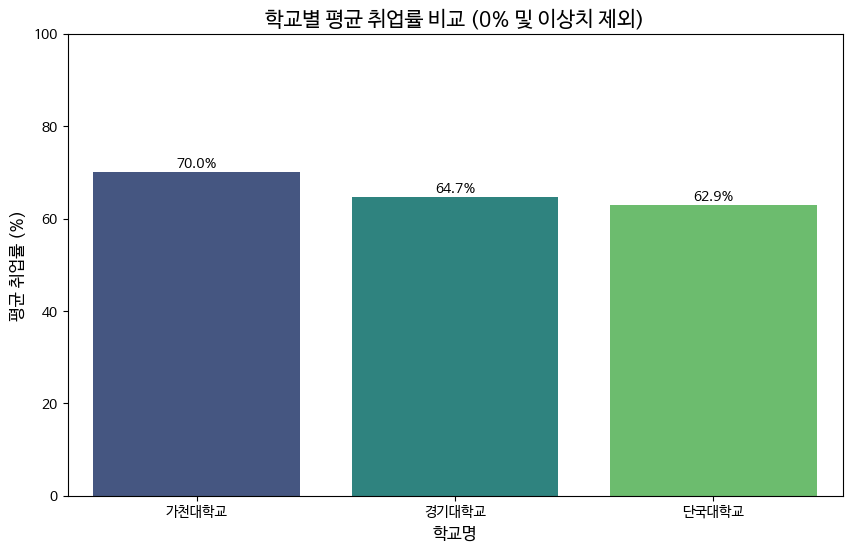

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Matplotlib 3.5+ version fix: Add font directly instead of using _rebuild()
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

employment_rate_col = '취업률(%) [B/{A-(C+D+E+F+G))]x100(%)'

# 학교별 평균 취업률 계산 (정리된 데이터 사용)
avg_employment_cleaned = df_filtered.groupby('학교명')[employment_rate_col].mean().reset_index()

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='학교명', y=employment_rate_col, data=avg_employment_cleaned, hue='학교명', palette='viridis', legend=False)
plt.title('학교별 평균 취업률 비교 (0% 및 이상치 제외)', fontsize=15)
plt.xlabel('학교명', fontsize=12)
plt.ylabel('평균 취업률 (%)', fontsize=12)
plt.ylim(0, 100)

for i, row in avg_employment_cleaned.iterrows():
    plt.text(i, row[employment_rate_col] + 1, f'{row[employment_rate_col]:.1f}%', ha='center')

plt.show()

### 단과대학별 평균 취업률 비교표 (이상치 및 0% 제외 후)

In [37]:
import pandas as pd

employment_rate_col = '취업률(%) [B/{A-(C+D+E+F+G))]x100(%)'

# '학교명'과 '단과대학명'을 기준으로 평균 취업률 계산 (정리된 데이터 사용)
college_avg_cleaned = df_filtered.groupby(['학교명', '단과대학명'])[employment_rate_col].mean().reset_index()

# 가독성을 위해 피벗 테이블 형태로 변환 (행: 단과대학, 열: 학교)
college_pivot_cleaned = college_avg_cleaned.pivot(index='단과대학명', columns='학교명', values=employment_rate_col)

# 소수점 첫째 자리까지 반올림하고 결측치(해당 학교에 없는 단과대학) 처리
college_pivot_cleaned = college_pivot_cleaned.round(1).fillna('-')

print("--- 가천대, 단국대, 경기대 단과대학별 평균 취업률 비교표 (0% 및 이상치 제외) ---")
display(college_pivot_cleaned)

--- 가천대, 단국대, 경기대 단과대학별 평균 취업률 비교표 (0% 및 이상치 제외) ---


학교명,가천대학교,경기대학교,단국대학교
단과대학명,,,
IT대학,64.6,-,-
IT융합대학,66.8,-,-
SW융합대학,-,-,65.7
간호대학,73.4,-,-
건축대학,-,-,70.6
경영경제대학,-,-,71.1
경영대학,68.1,-,-
공과대학,68.4,-,64.4
국제대학,-,-,69.1


### 단과대학별 평균 취업률 현황 (가천대, 경기대, 단국대 통합 - 이상치 및 0% 제외 후)

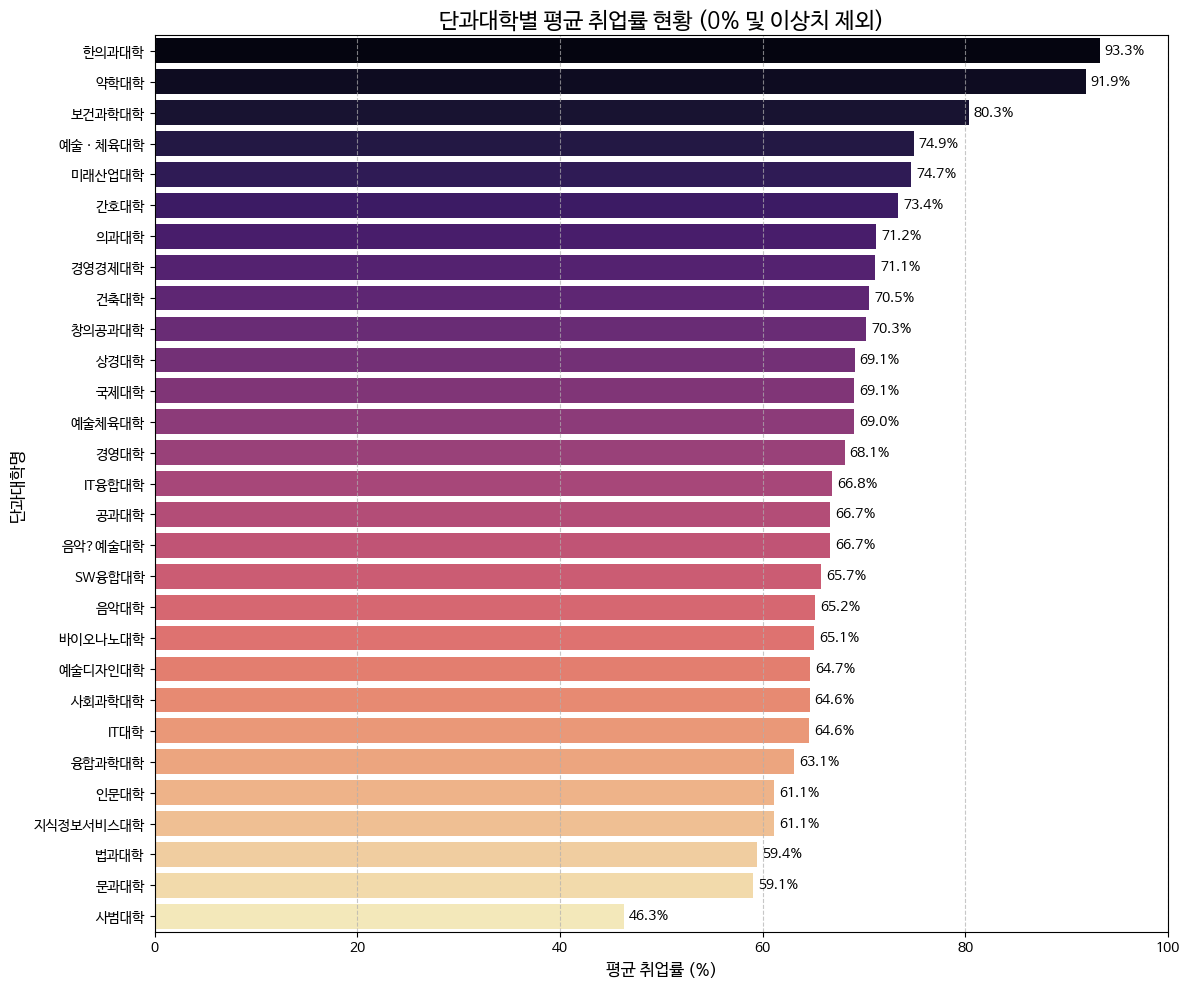

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

employment_rate_col = '취업률(%) [B/{A-(C+D+E+F+G))]x100(%)'

# 데이터 준비: 단과대학별 평균 취업률 계산 및 내림차순 정렬 (정리된 데이터 사용)
college_plot_data_cleaned = df_filtered.groupby('단과대학명')[employment_rate_col].mean().sort_values(ascending=False).reset_index()

# 시각화 설정
plt.figure(figsize=(12, 10))
sns.barplot(x=employment_rate_col, y='단과대학명', data=college_plot_data_cleaned, palette='magma', hue='단과대학명', legend=False)

# 제목 및 축 레이블 설정
plt.title('단과대학별 평균 취업률 현황 (0% 및 이상치 제외)', fontsize=16)
plt.xlabel('평균 취업률 (%)', fontsize=12)
plt.ylabel('단과대학명', fontsize=12)
plt.xlim(0, 100)

# 수치 표시
for i, row in college_plot_data_cleaned.iterrows():
    plt.text(row[employment_rate_col] + 0.5, i, f'{row[employment_rate_col]:.1f}%', va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()